# Distribuições de Probabilidade


- Bernoulli e Binomial. 
- Exponencial. 
- Gaussiana (Normal). 
- Rayleigh e Rice. 
- Poisson.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, expon, norm, rayleigh, rice, poisson

---

##  Bernoulli

Distribuição discreta que modela um experimento com dois resultados possíveis: sucesso (1) ou fracasso (0).

$$
P(X = x) = p^x (1 - p)^{1-x}, \quad x \in \{0,1\}
$$



---

## Binomial

Modela o número de sucessos em \(n\) tentativas independentes. Calcula a probabilidade de obter k sucessos em n tentativas independentes de um experimento de Bernoulli. Ex: Uma moeda tem duas faces: cara e coroa, podemos repetir o experimento de Bernoulli n vezes (Jogar a moeda n vezes).

$$
P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0,1,\dots,n
$$


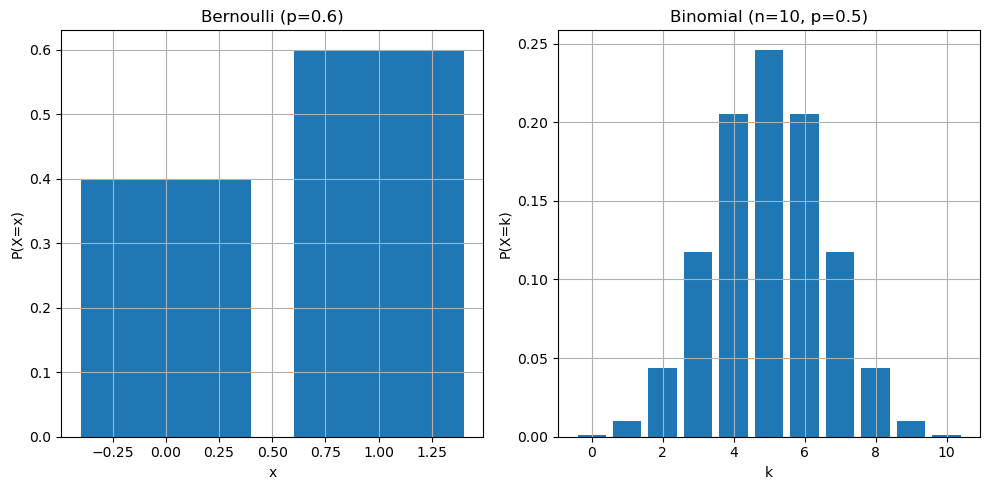

In [42]:
p1 = 0.6 # probabilidade de sucesso P(X=1)=0.6
x1 = np.array([0, 1]) # assumir dois valores 0 fracasso  e 1 sucesso
y1 = bernoulli.pmf(x1, p1) # probability mass function da distribuição de Bernoulli


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(x1, y1)
plt.title("Bernoulli (p=0.6)")
plt.xlabel("x")
plt.ylabel("P(X=x)")
plt.grid()

n, p2 = 10, 0.5 # número de tentativas (experimentos) e probabilidade de sucesso em cada tentativa
# repete-se um experimento 10 vezes e cada vez tem 50% de chance de sucesso
x2 = np.arange(0, n+1) # gera os valores de 0 até 10
y2 = binom.pmf(x2, n, p2)

# O valor mais provável é k=5, com chance de 50%, o mais esperado é metade dar sucesso.

plt.subplot(1, 2, 2)
plt.bar(x2, y2)
plt.title("Binomial (n=10, p=0.5)")
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.grid()

plt.tight_layout()

## Modelagem com distribuição de Bernoulli

- Modela eventos binários em telecomunicações e computação. Exemplos: erro de bit em canal digital (bit corretamente recebido vs. erro) ou sucesso de transmissão de pacote em rede (cada tentativa é um ensaio)

>https://doi.org/10.1109/WIOPT.2005.46 (The effect of retransmitted packet size preservation property on TCP goodput over links with Bernoulli bit-errors)


- Ikegawa et al. analisam o desempenho do protocolo de transporte em um enlace com erros, assumindo que os erros de bits ocorrem de forma independente, seguindo um modelo de Bernoulli (canal sem memória).
- Nesse modelo, cada bit transmitido pode estar correto ou incorreto com uma probabilidade fixa, independente dos demais bits.
- A partir dessa suposição, a probabilidade de erro de um pacote depende do seu tamanho: quanto maior o pacote, maior a chance de conter pelo menos um bit errado.
- Como o protocolo de transporte retransmite pacotes com erro mantendo o mesmo tamanho, pacotes grandes tendem a falhar repetidamente, aumentando o número de retransmissões.
- Os autores mostram que, quando a taxa de erro de bits é alta, esse efeito impacta significativamente o rendimento da conexão, reduzindo a quantidade de dados úteis entregues com sucesso.




---

## Exponencial

Distribuição contínua que descreve o tempo entre eventos.

$$
f(x) = \lambda e^{-\lambda x}, \quad x \ge 0
$$


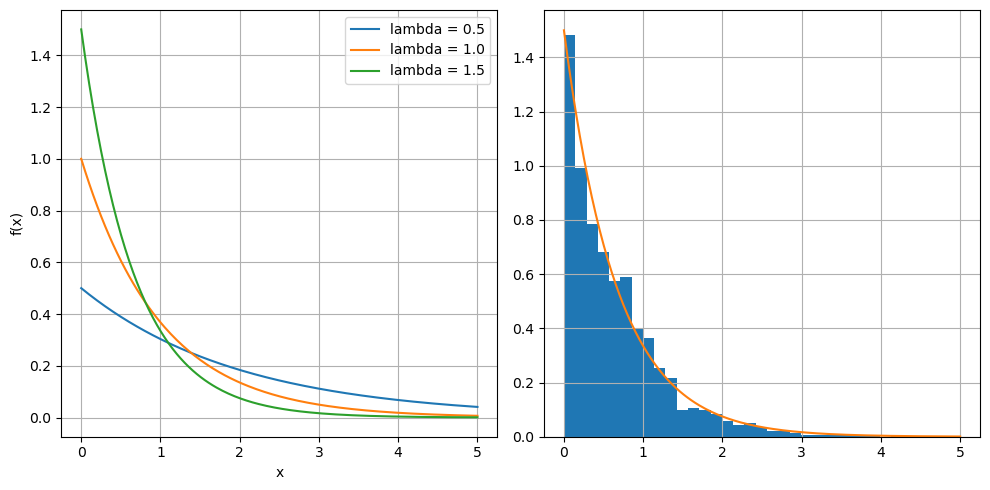

In [35]:
lam1 = 0.5 # Define a taxa λ da distribuição.
lam2 = 1.0
lam3 = 1.5
x = np.linspace(0, 5, 200) # 200 pontos espaçados entre 0 e 5
y1 = expon.pdf(x, scale=1/lam1)  #  função densidade de probabilidade da exponencial
y2 = expon.pdf(x, scale=1/lam2)
y3 = expon.pdf(x, scale=1/lam3)
# tem alta chance de eventos acontecerem rapidamente
# probabilidade diminui para tempos maiores

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, y1, label='lambda = 0.5')
plt.plot(x, y2, label='lambda = 1.0')
plt.plot(x, y3, label='lambda = 1.5')
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()


samples_exp = np.random.exponential(1/1.5, 1000)
x = np.linspace(0, 5, 200)

plt.subplot(1, 2, 2)
plt.hist(samples_exp, bins=30, density=True)
plt.plot(x, y3)
plt.grid()
plt.tight_layout()

# Modelagem com Distribuição Exponencial

A distribuição exponencial é utilizada para modelar:

## Tempo entre a chegada de pacotes em uma rede

> http://dx.doi.org/10.5755/j01.eee.20.3.6683

A distribuição exponencial aparece no artigo como uma das distribuições testadas para modelar o tempo entre chegadas de pacotes.

A distribuição exponencial é usada no artigo como um modelo clássico de referência (associado a chegadas Poisson), mas os resultados mostram que ela não descreve bem o tempo entre pacotes em redes reais, sendo superada por distribuições de cauda pesada como a Pareto.

Embora a distribuição exponencial seja teoricamente adequada para modelar tempos entre eventos aleatórios, ela não captura bem o comportamento real do tráfego de rede, que apresenta:
- rajadas (burstiness)
- dependência temporal

A distribuição que melhor descreve os dados é Pareto de segunda espécie (Lomax)



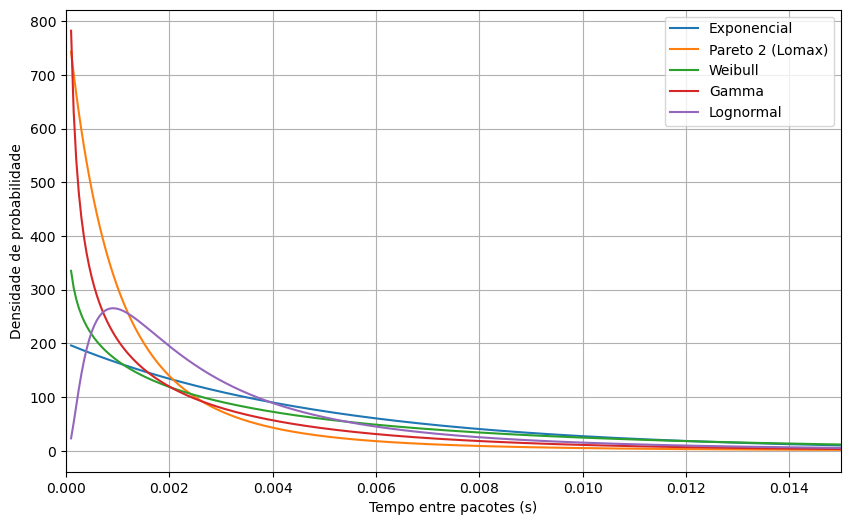

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lomax, weibull_min, gamma, lognorm

# Eixo x (tempo entre chegadas, em segundos por exemplo)
x = np.linspace(0.0001, 0.05, 1000)

# Parâmetros (valores típicos)
exp_dist = expon(scale=0.005)

# Pareto de segunda espécie (Lomax)
pareto_dist = lomax(c=2.5, scale=0.003)

# Weibull
weibull_dist = weibull_min(c=0.8, scale=0.005)

# Gamma
gamma_dist = gamma(a=0.5, scale=0.005)

# Lognormal
lognorm_dist = lognorm(s=1.0, scale=np.exp(-6))

exp_pdf = exp_dist.pdf(x)
pareto_pdf = pareto_dist.pdf(x)
weibull_pdf = weibull_dist.pdf(x)
gamma_pdf = gamma_dist.pdf(x)
lognorm_pdf = lognorm_dist.pdf(x)

plt.figure(figsize=(10, 6))

plt.plot(x, exp_pdf, label='Exponencial')
plt.plot(x, pareto_pdf, label='Pareto 2 (Lomax)')
plt.plot(x, weibull_pdf, label='Weibull')
plt.plot(x, gamma_pdf, label='Gamma')
plt.plot(x, lognorm_pdf, label='Lognormal')

plt.xlabel('Tempo entre pacotes (s)')
plt.ylabel('Densidade de probabilidade')
plt.xlim([0, 0.015])
plt.legend()
plt.grid()

plt.show()


---

## Normal (Gaussiana)

Distribuição contínua simétrica em torno da média.

$$
f(x) = \frac{1}{\sigma \sqrt{2\pi}} \; e^{-\frac{(x - \mu)^2}{2\sigma^2}}, \quad x \in \mathbb{R}
$$


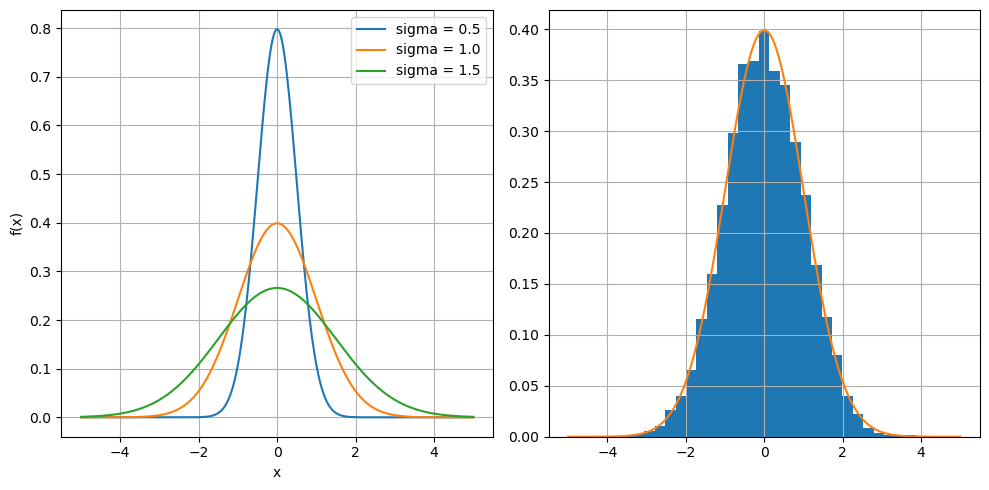

In [50]:
mu = 0 # média: centro da distribuição e  desvio padrão: controla a “largura” da curva
sigma1 = 0.5
sigma2 = 1
sigma3 = 1.5
x = np.linspace(-5, 5, 300) # 300 pontos entre -5 e 5
y1 = norm.pdf(x, loc=mu, scale=sigma1) #  função densidade de probabilidade da normal
y2 = norm.pdf(x, loc=mu, scale=sigma2)
y3 = norm.pdf(x, loc=mu, scale=sigma3)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, y1, label='sigma = 0.5')
plt.plot(x, y2, label='sigma = 1.0')
plt.plot(x, y3, label='sigma = 1.5')
plt.legend()
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

samples_normal = np.random.normal(0, 1, 10000)

plt.subplot(1, 2, 2)
plt.hist(samples_normal, bins=30, density=True)
plt.plot(x, y2)
plt.grid()

plt.tight_layout()

# Modelagem com Distribuição Gaussiana (Normal)

## Método de detecção de anomalias em dados de sensores de saúde usando distribuição Gaussiana

> https://doi.org/10.4018/ijcac.2021010103

O artigo propõe um método de detecção de anomalias baseado em distribuição Gaussiana que classifica dados de sensores como normais ou anômalos com base em sua probabilidade, alcançando maior precisão e eficiência que métodos tradicionais.

- Os autores analisam a detecção de anomalias em dados de sensores de saúde em nuvem, modelando o comportamento normal dos dados por meio de uma distribuição Gaussiana dentro de um esquema de aprendizado supervisionado
- Nesse modelo, cada variável medida (como temperatura, pressão ou batimento cardíaco) é representada por uma distribuição normal caracterizada por média e variância, assumindo que os valores normais se concentram em torno de um padrão
- A partir dessa suposição, calcula-se a probabilidade de novos dados com base nesses parâmetros: valores próximos da média têm alta probabilidade, enquanto valores distantes têm baixa probabilidade
- A probabilidade conjunta dos dados é obtida combinando as probabilidades de cada variável, permitindo avaliar se uma nova observação é consistente com o comportamento normal do sistema
- Os autores mostram que, ao classificar como anomalias os dados com baixa probabilidade, o método consegue identificar valores incorretos ou maliciosos com maior precisão e eficiência do que abordagens tradicionais, melhorando o desempenho geral do sistema de monitoramento


---

## Rayleigh

Distribuição contínua associada à magnitude de vetores com componentes gaussianas.

$$
f(x) = \frac{x}{\sigma^2} e^{-x^2/(2\sigma^2)}, \quad x \ge 0
$$

---

## Rice

Generalização da Rayleigh com componente determinística.

$$
f(x) = \frac{x}{\sigma^2} e^{-(x^2 + \nu^2)/(2\sigma^2)} I_0\left(\frac{x\nu}{\sigma^2}\right), \quad x \ge 0
$$

onde $I_0(\cdot)$ é a função de Bessel modificada de ordem zero.


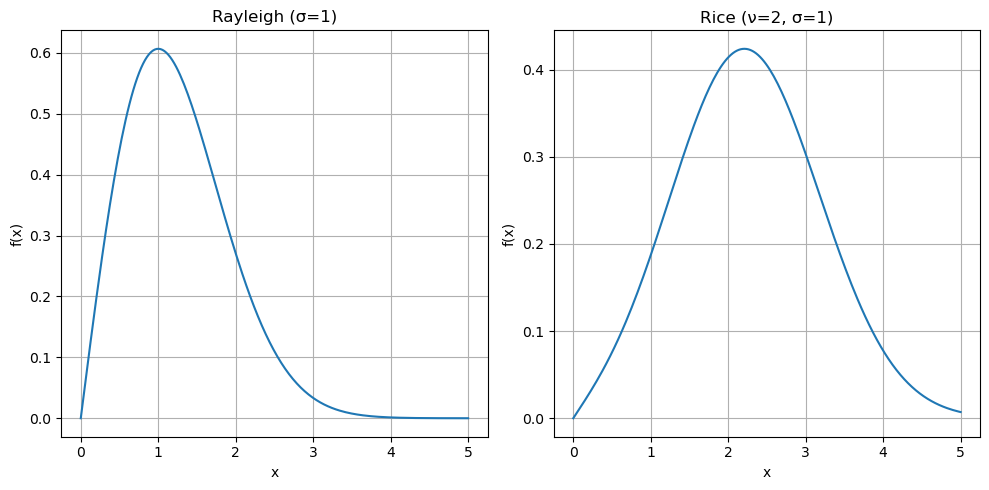

In [52]:
sigma = 1
x = np.linspace(0, 5, 200)
y1 = rayleigh.pdf(x, scale=sigma)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, y1)
plt.title("Rayleigh (σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

nu = 2

# parâmetro "b" = nu/sigma
y2= rice.pdf(x, b=nu/sigma, scale=sigma)

plt.subplot(1, 2, 2)
plt.plot(x, y2)
plt.title("Rice (ν=2, σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()

plt.tight_layout()

# Modelagem com Distribuição de Rayleigh / Rice

## Comportamento da magnitude da diferença entre imagens em dois instantes de tempo.

Imagine que você tem duas fotos do mesmo lugar, tiradas em momentos diferentes (por exemplo, antes e depois de um incêndio).
- O objetivo é descobrir: “O que mudou entre essas duas imagens?”

### Distribuição Rayleigh
- Representa pixels onde não houve mudança
- Valores pequenos (ruído, pequenas variações)
- “quase tudo igual, só pequenas diferenças naturais”

### Distribuição Rice
- Representa pixels onde houve mudança
- Valores maiores
- “algo realmente diferente aconteceu”

O artigo usa dois modelos matemáticos para separar automaticamente o que é “mudança real” do que é apenas “variação normal” entre duas imagens.

> https://doi.org/10.1109/TIP.2015.2474710

- Os autores analisam o problema de detecção de mudanças em imagens multiespectrais, modelando a distribuição da magnitude da imagem diferença como uma mistura de distribuições Rayleigh e Rice
- Nesse modelo, assume-se que os pixels sem mudança seguem uma distribuição Rayleigh, enquanto os pixels com mudança seguem uma distribuição de Rice, derivadas da hipótese de que os dados originais em cada banda são Gaussianos
- A partir dessa modelagem, a distribuição total dos dados é representada como uma mistura das duas distribuições, permitindo distinguir estatisticamente entre regiões com e sem mudança
- Como os parâmetros dessa mistura não são conhecidos, os autores utilizam o algoritmo de maximização da expectativa para estimá-los iterativamente a partir dos dados observados
- Com os parâmetros estimados, é possível definir um limiar ótimo baseado em decisão Bayesiana para classificar cada pixel como alterado ou não
- Os autores mostram que esse modelo teórico (Rayleigh–Rice) representa melhor os dados reais do que aproximações com distribuições Gaussianas, resultando em maior precisão na detecção de mudanças e redução significativa de erros



---

## Poisson

Distribuição discreta que modela o número de eventos em um intervalo fixo.

$$
P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k = 0,1,2,\dots
$$

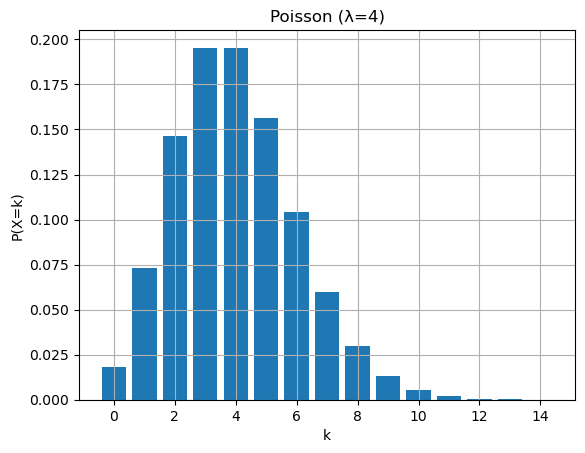

In [14]:
lam = 4 # número médio de eventos por intervalo
x = np.arange(0, 15)
y = poisson.pmf(x, lam) # Calcula a função de probabilidade

plt.figure()
plt.bar(x, y)
plt.title("Poisson (λ=4)")
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.grid()
plt.show()

# Modelagem com Distribuição de Poisson

## Distribuição de Poisson em Bioinformática - Ocorrência de padrões em sequências biológicas

> https://doi.org/10.1016/j.mbs.2008.11.006

A distribuição de Poisson é usada para modelar quantas vezes certos padrões (palavras de DNA) aparecem em uma sequência genética.

A ideia é que: ao percorrer uma sequência de DNA pequenas “palavras” (sequências de letras) aparecem várias vezes, essas ocorrências podem ser tratadas como eventos aleatórios

- Nesse modelo, cada padrão pode aparecer várias vezes ao longo da sequência, e assume-se que essas ocorrências acontecem de forma aproximadamente aleatória, com uma taxa média (como contar quantas vezes algo acontece em um intervalo)
- A partir dessa ideia, eles calculam qual seria o número “esperado” de vezes que cada padrão deveria aparecer e comparam com o número realmente observado
- Com isso, conseguem medir a probabilidade de uma sequência “parecer” com outra: se os padrões aparecem em quantidades semelhantes, as sequências são consideradas próximas; se diferem muito, são consideradas diferentes
- Os autores mostram que esse método baseado em probabilidade consegue comparar sequências de forma eficiente e construir árvores que indicam relações entre vírus e espécies, muitas vezes com resultados melhores do que métodos tradicionais



# Modelo para representar ruído em canais de comunicação quântica, combinando dois tipos de ruído:

### Ruído quântico (modelado por Poisson)
### Ruído clássico (ruído Gaussiano)

OBS: Ruído quântico é uma incerteza natural que existe no mundo microscópico (nível de átomos e partículas).

> https://doi.org/10.48550/arXiv.2409.04746

O artigo propõe aproximar um modelo complexo de ruído quântico (baseado em Poisson e Gaussiano) por uma mistura finita de distribuições Gaussianas, mostrando que a precisão depende da relação entre o número de componentes e o nível de ruído quântico.

- O ruído total pode ser modelado como uma mistura de distribuições Gaussianas, onde os pesos dessa mistura vêm de uma distribuição de Poisson. Isso resulta em um modelo chamado: mistura infinita de Gaussianas ponderadas por Poisson.
- Esse modelo original é matematicamente complexo e difícil de analisar (principalmente para calcular entropia).
- Os autores propõem aproximar essa mistura infinita por uma mistura finita de Gaussianas.
Ou seja: em vez de infinitos termos, usar apenas R componentes. Isso torna o modelo computacionalmente viável.



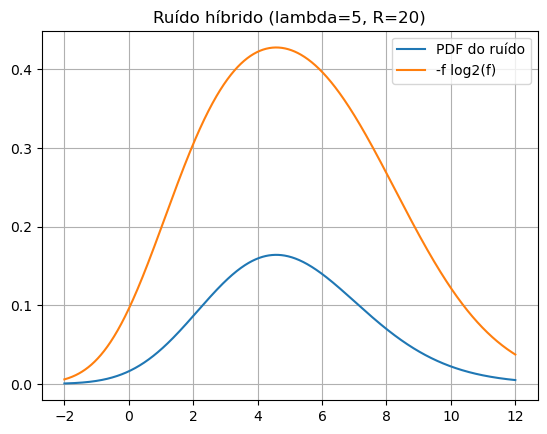

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import factorial, exp

# Parâmetros
lambda_ = 5
R = 20
mu = 0
sigma = 1

# Eixo x
z = np.linspace(-2, 12, 1000)

# Função mistura
f_z = np.zeros_like(z)

for i in range(R + 1):
    w_i = (exp(-lambda_) * lambda_**i) / factorial(i)
    f_z += w_i * norm.pdf(z, loc=i + mu, scale=sigma)

# Entropia aproximada
entropy = -f_z * np.log2(f_z + 1e-12)

# Plot
plt.figure()
plt.plot(z, f_z, label="PDF do ruído")
plt.plot(z, entropy, label="-f log2(f)")
plt.title(f"Ruído híbrido (lambda={lambda_}, R={R})")
plt.legend()
plt.grid()
plt.show()

# o ruído mais provável ocorre perto do valor médio do processo de Poisson
# A entropia é maior onde a probabilidade não é nem muito alta nem muito baixa


O gráfico mostra a distribuição do ruído híbrido (azul) e sua incerteza associada (laranja), evidenciando como a combinação de ruído quântico e clássico resulta em um comportamento probabilístico suave e bem aproximado quando o número de componentes é suficiente.